# Feature Engineering

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import RobustScaler
import numpy as np


In [2]:
df = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/raw/1970-2021_DISASTERS.xlsx - emdat data.csv')
df_earthquake = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_earthquake.csv')
df_flood = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_flood.csv')
#df_storm = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_storm.csv')
df_wildfire = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_wildfire.csv')

## Clean earthquake dataframe
- Impute missing values
- Scale

In [3]:
df_earthquake.head()

,Dis Mag Value,Total Deaths,Total Affected,Total Damages ('000 US$),duration_days,CPI,Year,Continent,Region
0,7.0,10000.0,NaN,NaN,0.0,15.001282,1970,Asia,Eastern Asia
1,7.0,NaN,3006.0,400.0,0.0,15.001282,1970,Americas,South America
2,7.0,29.0,88112.0,4000.0,0.0,15.001282,1970,Americas,South America
3,5.0,26.0,200.0,NaN,0.0,15.001282,1970,Asia,Southern Asia
4,8.0,85.0,2348973.0,236400.0,0.0,15.645257,1971,Americas,South America


In [4]:
df_earthquake.describe()
# May need to scale all features except dis mag value

,Dis Mag Value,Total Deaths,Total Affected,Total Damages ('000 US$),duration_days,CPI,Year
count,1093.000000,770.000000,1.038000e+03,4.760000e+02,1118.000000,1118.000000,1118.000000
mean,6.282708,1709.803896,1.879413e+05,1.741405e+06,0.030411,64.172894,1998.545617
std,1.011673,14369.732429,1.631831e+06,1.173739e+07,0.438691,22.816275,13.071636
min,3.000000,1.000000,1.000000e+00,2.000000e+00,0.000000,15.001282,1970.000000
25%,6.000000,2.000000,5.000000e+02,5.000000e+03,0.000000,47.898497,1989.000000
50%,6.000000,10.000000,4.395000e+03,5.500000e+04,0.000000,66.534994,2000.000000
75%,7.000000,50.750000,2.959375e+04,3.772000e+05,0.000000,83.189023,2009.000000
max,9.000000,242000.000000,4.597660e+07,2.100000e+08,9.000000,100.000000,2020.000000


### Drop duration_days column - shouldn't last for more than a day

In [5]:
df_earthquake['duration_days'].value_counts()

duration_days
0.0    1108
1.0       6
4.0       1
7.0       1
9.0       1
8.0       1
Name: count, dtype: int64

In [6]:
df_earthquake = df_earthquake.drop(columns = 'duration_days')

In [7]:
df_earthquake.isna().sum()

Dis Mag Value                25
Total Deaths                348
Total Affected               80
Total Damages ('000 US$)    642
CPI                           0
Year                          0
Continent                     0
Region                        0
dtype: int64

### Impute missing values in 'Dis Mag Value', 'Total Deaths', 'Total Affected', "Total Damages ('000 US$)"

In [8]:
cols_earthquake = ['Dis Mag Value', 'Total Deaths', 'Total Affected', "Total Damages ('000 US$)"]
df_earthquake[cols_earthquake] = df_earthquake[cols_earthquake].fillna(df_earthquake[cols_earthquake].median())

In [9]:
df_earthquake

,Dis Mag Value,Total Deaths,Total Affected,Total Damages ('000 US$),CPI,Year,Continent,Region
0,7.0,10000.0,4395.0,55000.0,15.001282,1970,Asia,Eastern Asia
1,7.0,10.0,3006.0,400.0,15.001282,1970,Americas,South America
2,7.0,29.0,88112.0,4000.0,15.001282,1970,Americas,South America
3,5.0,26.0,200.0,55000.0,15.001282,1970,Asia,Southern Asia
4,8.0,85.0,2348973.0,236400.0,15.645257,1971,Americas,South America
...,...,...,...,...,...,...,...,...
1113,5.0,10.0,278.0,55000.0,100.000000,2020,Asia,Western Asia
1114,7.0,115.0,6034.0,450000.0,100.000000,2020,Asia,Western Asia
1115,6.0,10.0,4395.0,1000.0,17.155360,1973,Americas,Northern America
1116,7.0,10.0,11.0,5750.0,17.155360,1973,Americas,Northern America


In [10]:
df_earthquake.isna().sum()

Dis Mag Value               0
Total Deaths                0
Total Affected              0
Total Damages ('000 US$)    0
CPI                         0
Year                        0
Continent                   0
Region                      0
dtype: int64

### Log transform Total Deaths,  Total Affected, Total Damages ('000 US$)
- Standard deviations much greater than means

In [11]:
df_earthquake['Total Deaths'] = np.log1p(df_earthquake['Total Deaths'])
df_earthquake['Total Affected'] = np.log1p(df_earthquake['Total Affected'])
df_earthquake["Total Damages ('000 US$)"] = np.log1p(df_earthquake["Total Damages ('000 US$)"])

### Recompute Damages Adjusted, Fatality Rate

In [12]:
df_earthquake['Fatality Rate'] = (df_earthquake['Total Deaths'] / df_earthquake['Total Affected']).clip(upper=1.0)

reference_cpi = df_earthquake.loc[df_earthquake['Year'] == df_earthquake['Year'].max(), 'CPI'].mean()

df_earthquake['Damages Adjusted'] = df_earthquake["Total Damages ('000 US$)"] * (reference_cpi / df_earthquake['CPI'])

<Axes: ylabel='Frequency'>

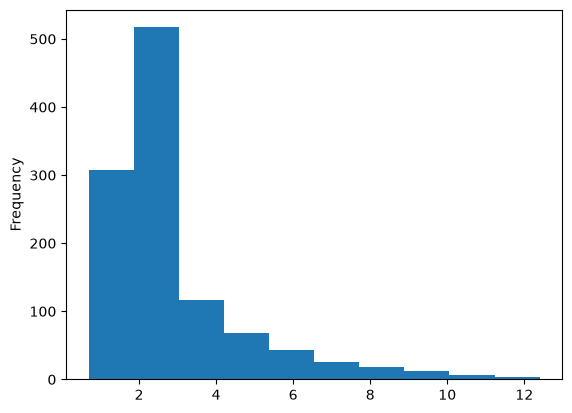

In [13]:
df_earthquake['Total Deaths'].plot(kind='hist')
## graph the rest

<Axes: ylabel='Frequency'>

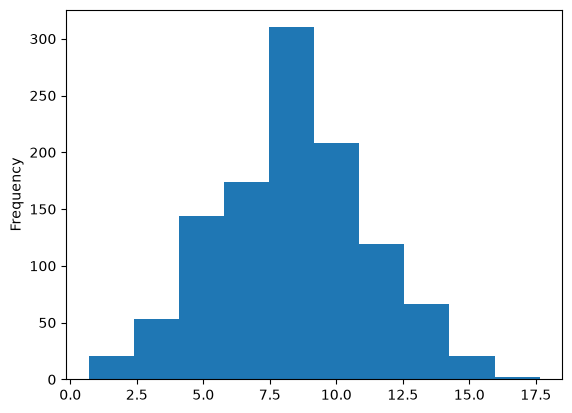

In [14]:
df_earthquake['Total Affected'].plot(kind='hist')

<Axes: ylabel='Frequency'>

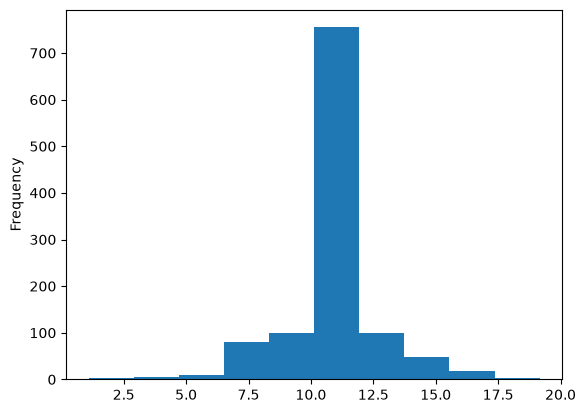

In [15]:
df_earthquake["Total Damages ('000 US$)"].plot(kind='hist')

<Axes: ylabel='Frequency'>

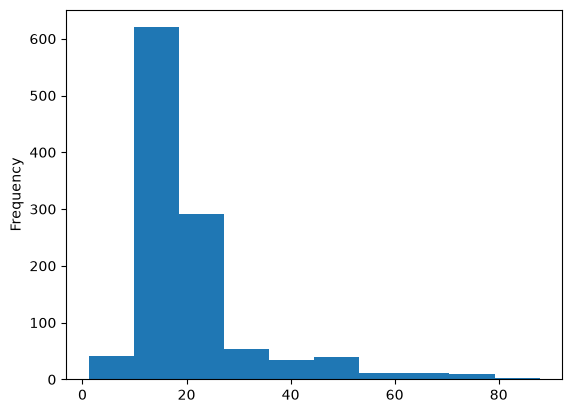

In [16]:
df_earthquake['Damages Adjusted'].plot(kind='hist')

<Axes: ylabel='Frequency'>

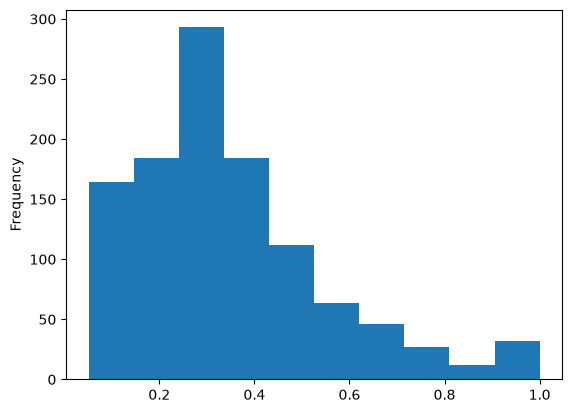

In [17]:
df_earthquake['Fatality Rate'].plot(kind='hist')

In [18]:
df_earthquake.isna().sum()

Dis Mag Value               0
Total Deaths                0
Total Affected              0
Total Damages ('000 US$)    0
CPI                         0
Year                        0
Continent                   0
Region                      0
Fatality Rate               0
Damages Adjusted            0
dtype: int64

In [19]:
earthquake_features = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'Fatality Rate', 'Damages Adjusted']

df_earthquake[earthquake_features].describe()

,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted
count,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000
mean,6.276386,2.797054,8.352713,0.348860,20.472579
std,1.001162,1.922150,2.859354,0.203930,12.184790
min,3.000000,0.693147,0.693147,0.051501,1.199632
25%,6.000000,1.609438,6.353921,0.213598,13.120850
50%,6.000000,2.397895,8.388450,0.302931,16.628146
75%,7.000000,3.135494,10.120526,0.439639,21.697596
max,9.000000,12.396697,17.643643,1.000000,87.863384


### Robust scale

In [20]:
scaler = RobustScaler()
df_earthquake[earthquake_features] = scaler.fit_transform(df_earthquake[earthquake_features])

In [21]:
df_earthquake[earthquake_features].describe()

,Dis Mag Value,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted
count,1118.000000,1118.000000,1118.000000,1118.000000,1.118000e+03
mean,0.276386,0.261562,-0.009488,0.203187,4.482390e-01
std,1.001162,1.259554,0.759133,0.902179,1.420677e+00
min,-3.000000,-1.117094,-2.043034,-1.112320,-1.798877e+00
25%,0.000000,-0.516663,-0.540149,-0.395206,-4.089309e-01
50%,0.000000,0.000000,0.000000,0.000000,2.070826e-16
75%,1.000000,0.483337,0.459851,0.604794,5.910691e-01
max,3.000000,6.552053,2.457171,3.083815,8.305625e+00


In [22]:
earthquake_features.append('Continent')
df_earthquake[earthquake_features].to_csv('earthquake_scaled.csv')

## Clean flood dataframe
- Impute missing values
- Scale
    - Log transform duration_days, CPI, Total Deaths, Total Affected, Total Damages

In [23]:
df_flood.head()

,Total Deaths,Total Affected,Total Damages ('000 US$),duration_days,CPI,Year,Continent,Region
0,36.0,NaN,25000.0,0.0,15.001282,1970,Americas,South America
1,NaN,NaN,200.0,NaN,15.001282,1970,Africa,Western Africa
2,NaN,10000000.0,25000.0,NaN,15.001282,1970,Asia,Southern Asia
3,172.0,104371.0,46000.0,0.0,15.001282,1970,Americas,South America
4,3.0,210.0,500.0,0.0,15.001282,1970,Americas,Caribbean


In [24]:
df_flood.describe()

,Total Deaths,Total Affected,Total Damages ('000 US$),duration_days,CPI,Year
count,3712.000000,4.368000e+03,1.717000e+03,4307.000000,5112.000000,5112.000000
mean,88.527209,8.708841e+05,5.081802e+05,8.972371,71.987548,2003.025039
std,793.494875,7.972097e+06,1.958388e+06,17.434542,20.781443,11.994233
min,1.000000,2.000000e+00,3.000000e+00,0.000000,15.001282,1970.000000
25%,5.000000,1.750000e+03,8.000000e+03,0.000000,60.604028,1996.000000
50%,15.000000,1.074000e+04,5.105000e+04,3.000000,75.457200,2005.000000
75%,41.000000,7.546175e+04,2.700000e+05,9.000000,88.710969,2012.000000
max,30000.000000,2.389730e+08,4.000000e+07,335.000000,100.000000,2020.000000


- Observe distribution of duration_days.
    - Apply log transformation.

<Axes: ylabel='Frequency'>

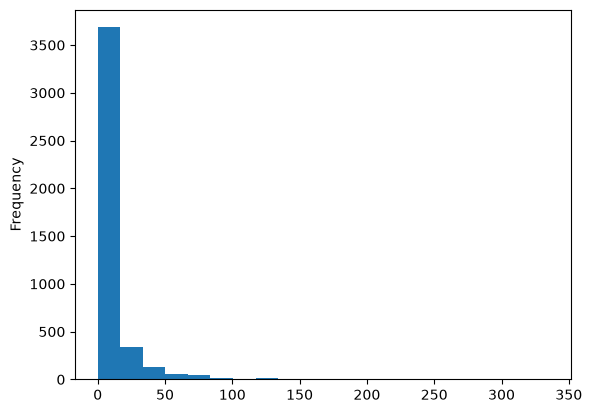

In [25]:
df_flood['duration_days'].plot(kind='hist', bins = 20)

- Observe distribution of Total Deaths.
    - Apply log transformation.

<Axes: ylabel='Frequency'>

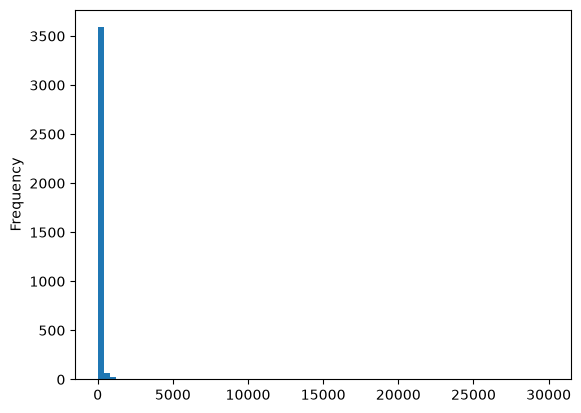

In [26]:
df_flood['Total Deaths'].plot(kind='hist', bins = 75)

- Observe distribution of Total Affected.
    - Apply log transformation.

<Axes: ylabel='Frequency'>

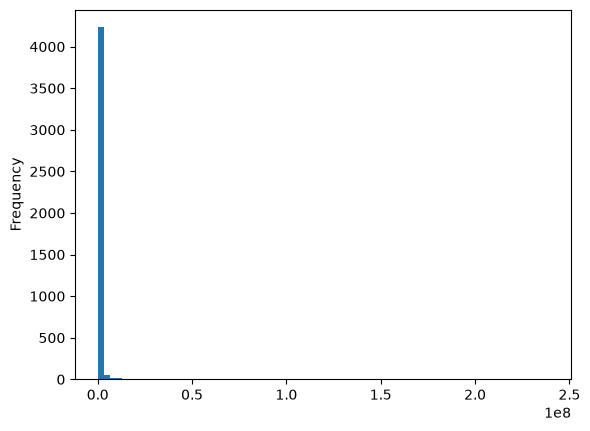

In [27]:
df_flood['Total Affected'].plot(kind='hist', bins = 75)

- Observe distribution of Total Damages.
    - Apply log transformation.

<Axes: ylabel='Frequency'>

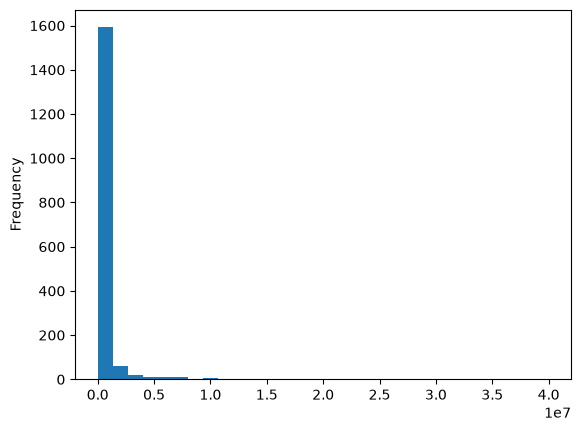

In [28]:
df_flood["Total Damages ('000 US$)"].plot(kind='hist', bins = 30)

### Impute 'Dis Mag Value', 'Total Deaths', 'Total Affected', "Total Damages ('000 US$)"

In [29]:
cols_flood = ['Total Deaths', 'Total Affected', "Total Damages ('000 US$)", 'duration_days']
df_flood[cols_flood] = df_flood[cols_flood].fillna(df_flood[cols_flood].median())

### Log transform Total Deaths,  Total Affected, Total Damages ('000 US$), duration_days
- Standard deviations much greater than means

In [30]:
df_flood['duration_days'] = np.log1p(df_flood['duration_days'])
df_flood['Total Deaths'] = np.log1p(df_flood['Total Deaths'])
df_flood['Total Affected'] = np.log1p(df_flood['Total Affected'])
df_flood["Total Damages ('000 US$)"] = np.log1p(df_flood["Total Damages ('000 US$)"])

### Recompute Damages Adjusted, Fatality Rate

In [31]:
df_flood['Fatality Rate'] = (df_flood['Total Deaths'] / df_flood['Total Affected']).clip(upper=1.0)

reference_cpi = df_flood.loc[df_flood['Year'] == df_flood['Year'].max(), 'CPI'].mean()

df_flood['Damages Adjusted'] = df_flood["Total Damages ('000 US$)"] * (reference_cpi / df_flood['CPI'])

<Axes: ylabel='Frequency'>

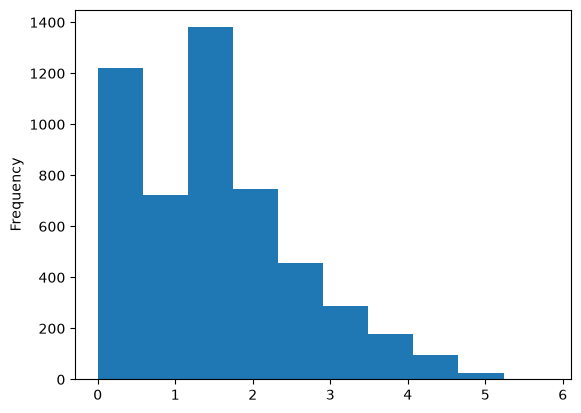

In [32]:
df_flood['duration_days'].plot(kind='hist')

<Axes: ylabel='Frequency'>

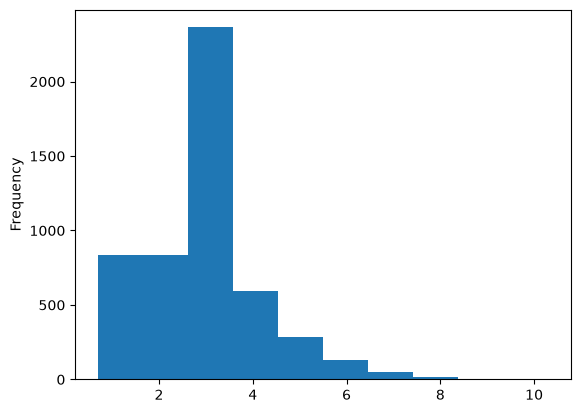

In [33]:
df_flood['Total Deaths'].plot(kind='hist')

<Axes: ylabel='Frequency'>

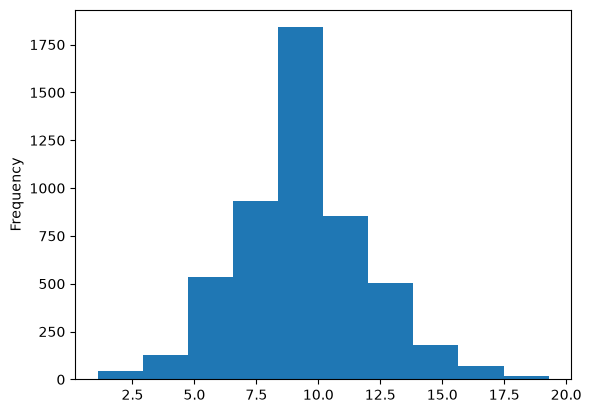

In [34]:
df_flood['Total Affected'].plot(kind='hist')

<Axes: ylabel='Frequency'>

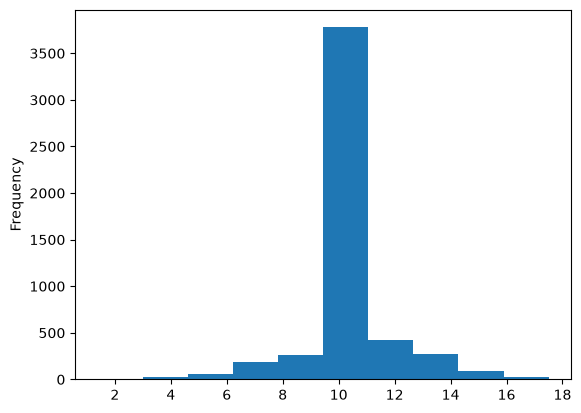

In [35]:
df_flood["Total Damages ('000 US$)"].plot(kind='hist')

<Axes: ylabel='Frequency'>

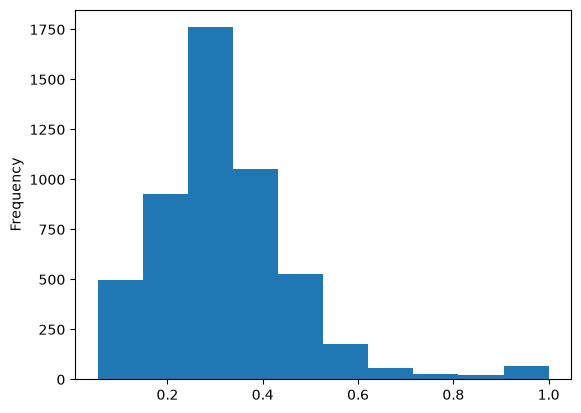

In [36]:
df_flood['Fatality Rate'].plot(kind='hist')

<Axes: ylabel='Frequency'>

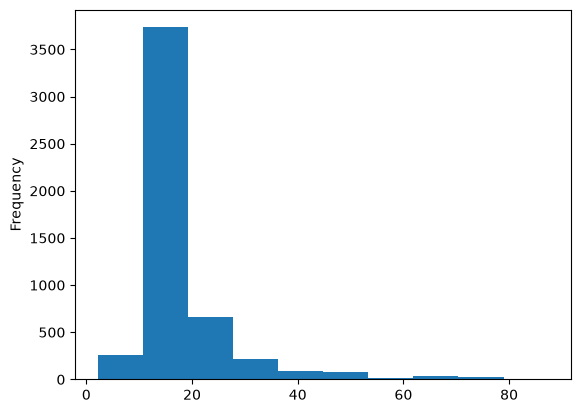

In [37]:
df_flood['Damages Adjusted'].plot(kind='hist')

### Robust scale

In [38]:
scaler = RobustScaler()
flood_features = ['duration_days', 'Total Deaths', 'Total Affected', 'Fatality Rate', 'Damages Adjusted']
df_flood[flood_features] = scaler.fit_transform(df_flood[flood_features])

In [39]:
df_flood[flood_features].describe()

,duration_days,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted
count,5112.000000,5112.000000,5112.000000,5112.000000,5112.000000
mean,0.050635,0.101388,0.027808,0.144315,0.474134
std,0.821048,1.195217,0.856735,0.970545,1.572487
min,-1.000000,-2.019622,-2.669183,-1.590071,-2.010296
25%,-0.500000,-0.456483,-0.498255,-0.433554,-0.379333
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.543517,0.501745,0.566446,0.620667
max,3.196159,7.319595,3.265053,4.525604,12.034248


In [61]:
flood_features.append('Continent')
df_flood[flood_features].to_csv('flood_scaled.csv')

In [41]:
df_flood.isna().sum()

Total Deaths                0
Total Affected              0
Total Damages ('000 US$)    0
duration_days               0
CPI                         0
Year                        0
Continent                   0
Region                      0
Fatality Rate               0
Damages Adjusted            0
dtype: int64

In [42]:
df['Disaster Type'].value_counts()[['Impact', 'Mass movement (dry)', 'Insect infestation', 'Animal accident']]

Disaster Type
Impact                  1
Mass movement (dry)    41
Insect infestation     93
Animal accident         1
Name: count, dtype: int64

## Clean wildfire dataframe
- Impute missing values
- Scale

In [3]:
df_wildfire.head()

,Dis Mag Value,Total Deaths,Total Affected,duration_days,CPI,Year
0,NaN,NaN,NaN,NaN,15.001282,1970
1,NaN,NaN,NaN,NaN,15.001282,1970
2,NaN,NaN,NaN,NaN,15.645257,1971
3,NaN,NaN,NaN,NaN,15.645257,1971
4,NaN,NaN,NaN,NaN,16.157212,1972


In [4]:
df_wildfire.describe()

,Dis Mag Value,Total Deaths,Total Affected,duration_days,CPI,Year
count,183.000000,181.000000,2.530000e+02,281.000000,436.000000,436.000000
mean,6539.622951,15.690608,6.827258e+04,10.911032,67.055534,2000.224771
std,51051.997020,29.959109,6.596322e+05,27.483552,20.944548,12.128998
min,1.000000,1.000000,1.000000e+00,0.000000,15.001282,1970.000000
25%,80.500000,2.000000,2.000000e+02,0.000000,57.271483,1994.000000
50%,349.000000,5.000000,1.000000e+03,0.000000,66.534994,2000.000000
75%,1340.000000,15.000000,4.508000e+03,7.000000,83.189023,2009.000000
max,680000.000000,240.000000,1.000220e+07,213.000000,100.000000,2020.000000


In [5]:
df_wildfire.isna().sum()

Dis Mag Value     253
Total Deaths      255
Total Affected    183
duration_days     155
CPI                 0
Year                0
dtype: int64

<Axes: ylabel='Frequency'>

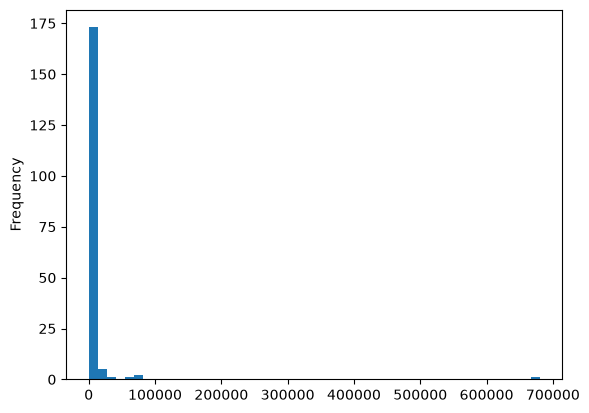

In [6]:
df_wildfire['Dis Mag Value'].plot(kind='hist', bins = 50)

<Axes: ylabel='Frequency'>

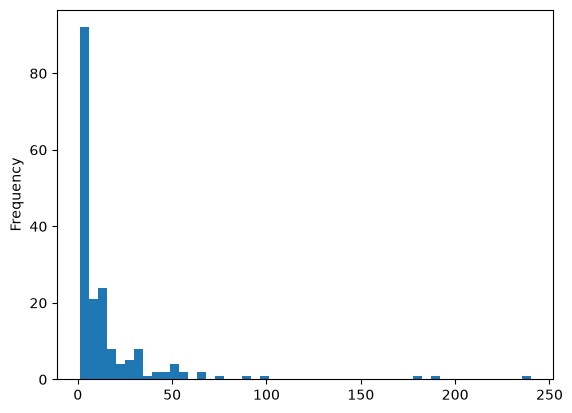

In [7]:
df_wildfire['Total Deaths'].plot(kind='hist', bins = 50)

<Axes: ylabel='Frequency'>

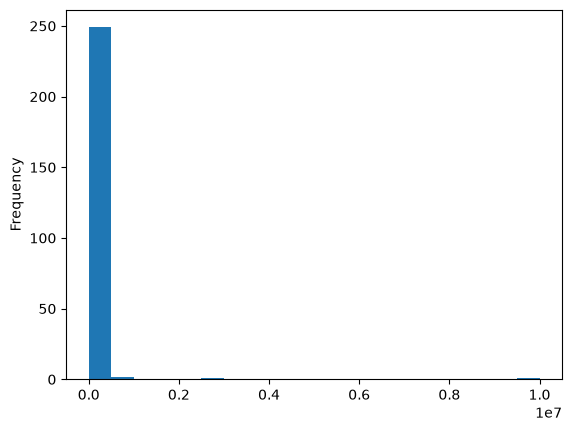

In [8]:
df_wildfire['Total Affected'].plot(kind='hist', bins = 20)

<Axes: ylabel='Frequency'>

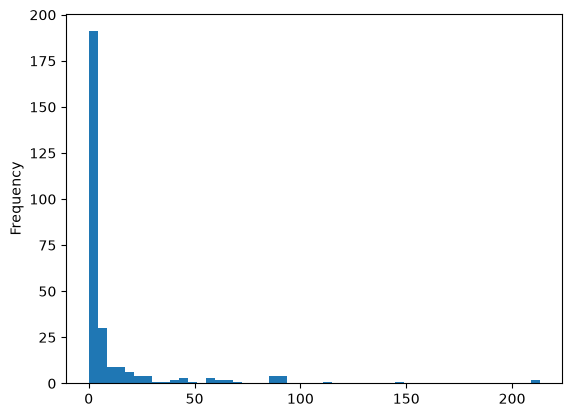

In [9]:
df_wildfire['duration_days'].plot(kind='hist', bins=50)

### Impute missing values Dis Mag Value, Total Deaths, Total Affected, duration_days

In [10]:
cols_wildfire = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'duration_days']
df_wildfire[cols_wildfire] = df_wildfire[cols_wildfire].fillna(df_wildfire[cols_wildfire].median())

### Log transformation on Dis Mag Value, Total Deaths, Total Affected, duration_days

In [11]:
df_wildfire['duration_days'] = np.log1p(df_wildfire['duration_days'])
df_wildfire['Dis Mag Value'] = np.log1p(df_wildfire['Dis Mag Value'])
df_wildfire['Total Affected'] = np.log1p(df_wildfire['Total Affected'])
df_wildfire['Total Deaths'] = np.log1p(df_wildfire['Total Deaths'])

<Axes: ylabel='Frequency'>

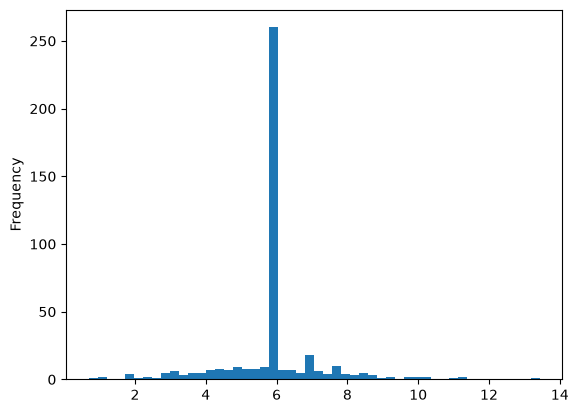

In [12]:
df_wildfire['Dis Mag Value'].plot(kind='hist', bins = 50)

<Axes: ylabel='Frequency'>

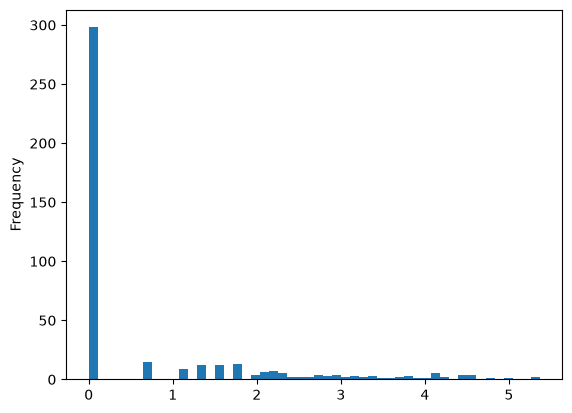

In [13]:
df_wildfire['duration_days'].plot(kind='hist', bins = 50)

<Axes: ylabel='Frequency'>

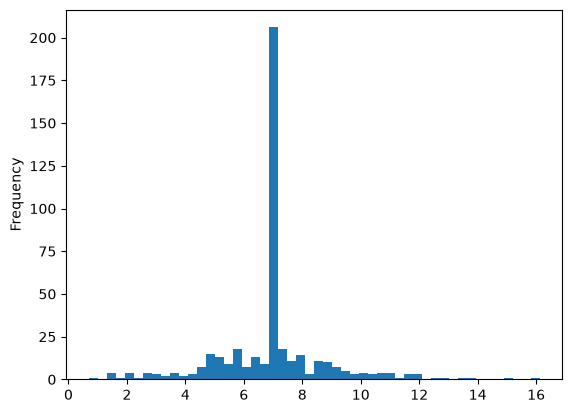

In [14]:
df_wildfire['Total Affected'].plot(kind='hist', bins = 50)

<Axes: ylabel='Frequency'>

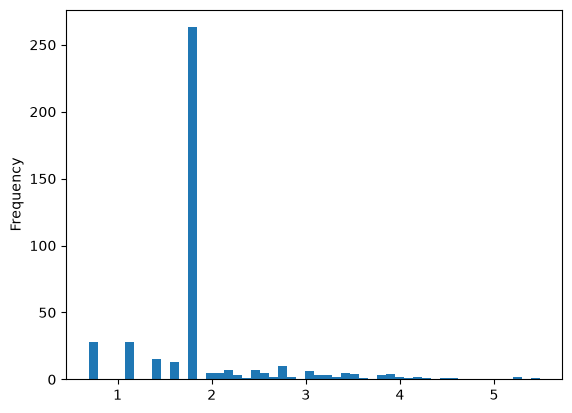

In [15]:
df_wildfire['Total Deaths'].plot(kind='hist', bins = 50)

### Recompute Fatality Rate

In [16]:
df_wildfire['Fatality Rate'] = (df_wildfire['Total Deaths'] / df_wildfire['Total Affected']).clip(upper=1.0)

<Axes: ylabel='Frequency'>

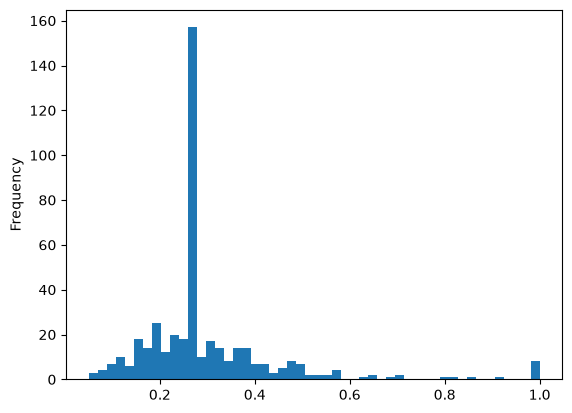

In [17]:
df_wildfire['Fatality Rate'].plot(kind = 'hist', bins = 50)

## Robust scale

In [18]:
scaler = RobustScaler()
cols_wildfire = ['Dis Mag Value', 'Total Deaths', 'Total Affected', 'duration_days', 'Fatality Rate']
df_wildfire[cols_wildfire] = scaler.fit_transform(df_wildfire[cols_wildfire])

In [19]:
df_wildfire[cols_wildfire].describe()

,Dis Mag Value,Total Deaths,Total Affected,duration_days,Fatality Rate
count,436.000000,436.000000,436.000000,436.000000,436.000000
mean,0.004399,0.116485,0.017555,0.537556,0.396796
std,1.395368,0.735690,2.719873,0.928794,1.637968
min,-5.164786,-1.098612,-8.864125,0.000000,-2.245083
25%,0.000000,0.000000,-0.605730,0.000000,-0.288457
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.394270,1.000000,0.711543
max,7.571916,3.693037,13.133823,3.870733,7.949480


In [24]:
df_wildfire[cols_wildfire].to_csv('wildfire_scaled.csv')